# Mini-GPT: Creative News Headline Generation

Build a **Decoder-only Transformer** (like GPT-2) to generate short news headlines. We will focus on how a model learns to predict the "next word" while being restricted from seeing the future.

In [1]:
import torch
import torch.nn as nn
import torch.optim as opt
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
import random
import os

In [2]:
# 1. Dataset: Synthetic News Headlines
headlines = [
    "tech stocks rise as ai demand grows, this year",
    "global climate summit reaches major breakthrough and hope for future",
    "new space mission to explore distant moon",
    "central bank raises rates to fight inflation",
    "electric cars dominate the auto market shift but gas prices soar",
    "archaeologists find lost city in desert this is amazing",
    "renewable energy set to power small cities",
    "advances in medicine offer new hope for patients",
    "cybersecurity threats rise amid remote work shift",
    "underwater drones discover rare deep sea species",
    "global trade eases as supply chains normalize",
    "autonomous ships set sail on historic journey",
    "quantum computers solve complex math problems fast",
    "fusion energy test achieves net power gain",
    "mars colony plans expand with new funding"
]

# Build Vocabulary
vocab = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2}
all_words = " ".join(headlines).lower().split()
for w in all_words:
    if w not in vocab: vocab[w] = len(vocab)

inv_v = {i: w for w, i in vocab.items()}
vocab_sz = len(vocab)
print(f"Vocabulary Size: {vocab_sz}")

Vocabulary Size: 105


In [3]:
vocab

{'<PAD>': 0,
 '<SOS>': 1,
 '<EOS>': 2,
 'tech': 3,
 'stocks': 4,
 'rise': 5,
 'as': 6,
 'ai': 7,
 'demand': 8,
 'grows,': 9,
 'this': 10,
 'year': 11,
 'global': 12,
 'climate': 13,
 'summit': 14,
 'reaches': 15,
 'major': 16,
 'breakthrough': 17,
 'and': 18,
 'hope': 19,
 'for': 20,
 'future': 21,
 'new': 22,
 'space': 23,
 'mission': 24,
 'to': 25,
 'explore': 26,
 'distant': 27,
 'moon': 28,
 'central': 29,
 'bank': 30,
 'raises': 31,
 'rates': 32,
 'fight': 33,
 'inflation': 34,
 'electric': 35,
 'cars': 36,
 'dominate': 37,
 'the': 38,
 'auto': 39,
 'market': 40,
 'shift': 41,
 'but': 42,
 'gas': 43,
 'prices': 44,
 'soar': 45,
 'archaeologists': 46,
 'find': 47,
 'lost': 48,
 'city': 49,
 'in': 50,
 'desert': 51,
 'is': 52,
 'amazing': 53,
 'renewable': 54,
 'energy': 55,
 'set': 56,
 'power': 57,
 'small': 58,
 'cities': 59,
 'advances': 60,
 'medicine': 61,
 'offer': 62,
 'patients': 63,
 'cybersecurity': 64,
 'threats': 65,
 'amid': 66,
 'remote': 67,
 'work': 68,
 'underwater

## Conceptual Anatomy: The Causal Mask

Transformers process sequences in parallel. To **generate** text, the model must predict word $i+1$ using only words $0...i$. 

We use a `mask` filled with `-inf` for future positions so the Softmax function turns those probabilities to absolute zero.

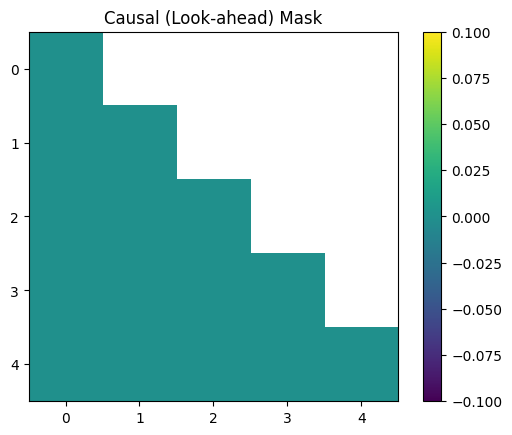

In [4]:
def get_causal_mask(sz):
    mask = torch.tril(torch.ones(sz, sz)) == 1
    mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
    return mask

plt.imshow(get_causal_mask(5).detach().numpy())
plt.title("Causal (Look-ahead) Mask")
plt.colorbar()
plt.show()

## The Decoder block
A standard Transformer Decoder Block with Multi-Head Attention, Feed-Forward Network, and Residual connections.

In [5]:
class DecoderBlock(nn.Module):
    def __init__(self, d_m, h, d_ff):
        super().__init__()
        self.mha = nn.MultiheadAttention(d_m, h, batch_first=True)
        self.norm1 = nn.LayerNorm(d_m)
        self.norm2 = nn.LayerNorm(d_m)
        self.ff = nn.Sequential(
            nn.Linear(d_m, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_m)
        )

    def forward(self, x, mask):
        attn_out, _ = self.mha(x, x, x, attn_mask=mask, need_weights=False)
        x = self.norm1(x + attn_out)
        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)
        return x

class MiniGPT(nn.Module):
    def __init__(self, v_sz, d_m, h, d_ff, max_l):
        super().__init__()
        self.w_emb = nn.Embedding(v_sz, d_m)
        self.p_emb = nn.Embedding(max_l, d_m)
        self.block = DecoderBlock(d_m, h, d_ff)
        self.ln = nn.LayerNorm(d_m)
        self.out = nn.Linear(d_m, v_sz)
        
    def forward(self, x):
        b, seq_l = x.size()
        mask = get_causal_mask(seq_l).to(x.device)
        pos = torch.arange(0, seq_l, device=x.device).unsqueeze(0)
        h = self.w_emb(x) + self.p_emb(pos)
        h = self.block(h, mask)
        return self.out(self.ln(h))

## Training: Memorizing the Headlines

Epoch 50, Loss: 0.3485
Epoch 100, Loss: 0.3284
Epoch 150, Loss: 0.3237
Epoch 200, Loss: 0.3215
Epoch 250, Loss: 0.3202


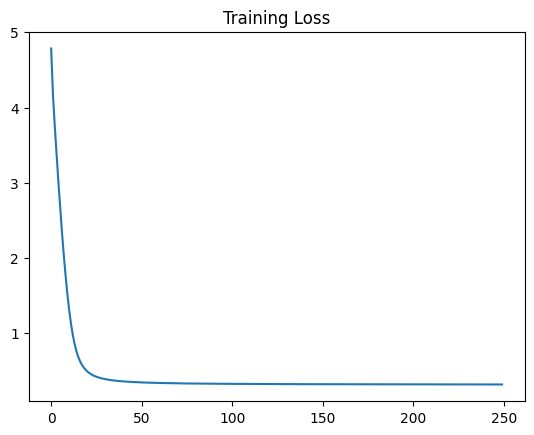

In [6]:
def get_data():
    inputs, targets = [], []
    for line in headlines:
        words = ["<SOS>"] + line.lower().split() + ["<EOS>"]
        ids = [vocab[w] for w in words]
        inputs.append(torch.tensor(ids[:-1], dtype=torch.long))
        targets.append(torch.tensor(ids[1:], dtype=torch.long))
    return inputs, targets

inputs, targets = get_data()
mod = MiniGPT(vocab_sz, 64, 4, 128, 50)
optz = opt.Adam(mod.parameters(), lr=0.001)
crit = nn.CrossEntropyLoss()

losses = []
for epoch in range(250):
    total_loss = 0
    for x, y in zip(inputs, targets):
        optz.zero_grad()
        pred = mod(x.unsqueeze(0))
        loss = crit(pred.view(-1, vocab_sz), y)
        loss.backward()
        optz.step()
        total_loss += loss.item()
    losses.append(total_loss/len(inputs))
    if (epoch+1) % 50 == 0: print(f"Epoch {epoch+1}, Loss: {losses[-1]:.4f}")

plt.plot(losses)
plt.title("Training Loss")
plt.show()
torch.save(mod.state_dict(), "minigpt_headline.pth")

## Decoding Strategies: Creativity vs. Accuracy

If we always pick the most likely word (**Greedy Decoding**), the model will often repeat the training data exactly. To get "new" sentences, we use **Sampling with Temperature**.

### Concept
1. **Greedy (`argmax`)**: Deterministic, safe, but repetitive.
2. **Stochastic Sampling**: Pick words based on probability. This allows the model to "mix" phrases from different headlines.
3. **Temperature ($T$)**: 
   - $T < 1.0$: Makes the model more confident/conservative (sharpens distributions).
   - $T > 1.0$: Makes the model more "creative"/chaotic (flattens distributions).

In [7]:
def generate(prompt, max_len=15, temp=1.0):
    m = MiniGPT(vocab_sz, 64, 4, 128, 50)
    m.load_state_dict(torch.load("minigpt_headline.pth"))
    m.eval()
    
    words = ["<SOS>"] + prompt.lower().split()
    ids = [vocab[w] for w in words]
    x = torch.tensor(ids, dtype=torch.long).unsqueeze(0)
    
    for _ in range(max_len):
        with torch.no_grad():
            logits = m(x)[:, -1, :] / temp # Apply temperature
            probs = F.softmax(logits, dim=-1)
            
            # Sample from the distribution instead of argmax
            next_id = torch.multinomial(probs, num_samples=1).item()
            
            if next_id == vocab["<EOS>"]: break
            ids.append(next_id)
            x = torch.tensor(ids, dtype=torch.long).unsqueeze(0)
            
    return " ".join([inv_v[i] for i in ids if i > 2])

print(generate("Global", temp=0.1)) # Greedy-style (Temp=0.1)

for _ in range(3): # Generate 3 headlines
    print(generate("global", temp=1.2))

global trade eases as supply chains normalize
global climate summit reaches major breakthrough and hope for future
global trade eases as supply chains normalize
global trade eases as supply chains normalize


In [8]:
headlines

['tech stocks rise as ai demand grows, this year',
 'global climate summit reaches major breakthrough and hope for future',
 'new space mission to explore distant moon',
 'central bank raises rates to fight inflation',
 'electric cars dominate the auto market shift but gas prices soar',
 'archaeologists find lost city in desert this is amazing',
 'renewable energy set to power small cities',
 'advances in medicine offer new hope for patients',
 'cybersecurity threats rise amid remote work shift',
 'underwater drones discover rare deep sea species',
 'global trade eases as supply chains normalize',
 'autonomous ships set sail on historic journey',
 'quantum computers solve complex math problems fast',
 'fusion energy test achieves net power gain',
 'mars colony plans expand with new funding']